In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2 # Used for Grad-CAM visualization
from sklearn.utils.class_weight import compute_class_weight
IMG_SIZE = 224
BATCH_SIZE = 32 
CLASSES = ['glioma', 'meningioma', 'pituitary', 'notumor']
NUM_CLASSES = 4

In [2]:
TRAIN_DIR = 'archive\Training'
TEST_DIR = 'archive\Testing'

In [3]:
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import optimizers

# --- 1. CONFIGURATION ---
TRAIN_DIR = 'archive/Training' 
IMG_SIZE = 224
BATCH_SIZE = 32
N_FOLDS = 5 
# --- 2. PREPARE DATA FRAME ---
filepaths = []
labels = []


if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Directory not found: {TRAIN_DIR}. Please check the path.")

classes_list = sorted(os.listdir(TRAIN_DIR)) 

for class_name in classes_list:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_dir):
        for filename in os.listdir(class_dir):
            filepaths.append(os.path.join(class_dir, filename))
            labels.append(class_name)

df = pd.DataFrame({
    'filename': filepaths,
    'class': labels
})

print(f"Found {len(df)} images belonging to {len(classes_list)} classes.")

# --- 3. CROSS VALIDATION SETUP ---
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Augmentation arguments
train_datagen_args = dict(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,        
    rotation_range=40,       
    width_shift_range=0.2,   
    height_shift_range=0.2,  
    zoom_range=0.2,          
    horizontal_flip=True,    
    fill_mode='bilinear'
)

val_datagen_args = dict(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

acc_per_fold = []
loss_per_fold = []
all_y_true = []
all_y_pred = []
fold_accuracies_raw = []
fold_no = 1

Found 5712 images belonging to 4 classes.


In [4]:
# --- Custom Channel Attention Layer ---

class ChannelAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)

    def build(self, input_shape):

        self.channels = input_shape[-1]

        
        self.w = self.add_weight(name='attention_weights',
                                 shape=(self.channels,),
                                 initializer='ones', 
                                 trainable=True)
        super(ChannelAttention, self).build(input_shape)

    def call(self, inputs):
        # 1. Compute attention scores (alpha) using softmax
        alpha = tf.nn.softmax(self.w)

        # 2. Apply attention scores to the input vector (v_att = alpha * v)
        v_att = inputs * alpha
        return v_att

    def get_config(self):
        # saving/loading the model
        config = super(ChannelAttention, self).get_config()
        return config

# --- 4. Model Building (VGG16 + BatchNorm + Fine-Tuning) ---
def build_optimized_vgg_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=4):
    
    # Load VGG16
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # --- Fine-Tuning Strategy ---
    # unfreezes the last convolutional block (Block 5) to let it adapt to MRI textures, while keeping earlier layers (edges/shapes) frozen.
    base_model.trainable = True
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == 'block5_conv1':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    inputs = base_model.input
    x = base_model.output

    # Attention & Pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = ChannelAttention(name='channel_attention')(x)
    
    # --- Classification Head Improvements ---
    # Adding BatchNormalization to stabilize training at high accuracy
    x = layers.BatchNormalization()(x) 
    x = layers.Dropout(0.4)(x) # Slightly reduced dropout
    
    x = layers.Dense(256, activation='relu')(x) # Increased density
    x = layers.BatchNormalization()(x) # Added another BatchNorm
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs, name='VGG16_Optimized')

model = build_optimized_vgg_model()
# Create the model
model = build_optimized_vgg_model()
model.summary() 

Model: "VGG16_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pool                      │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ channel_attention (ChannelAttention) │ (None, 512)                 │             5

 Total params: 14,850,628 (56.65 MB)

 Trainable params: 7,213,828 (27.52 MB)

 Non-trainable params: 7,636,800 (29.13 MB)


--- Training Fold 1 / 5 ---
Found 4569 validated image filenames belonging to 4 classes.
Found 1143 validated image filenames belonging to 4 classes.


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.5557 - loss: 1.1614 - val_accuracy: 0.5241 - val_loss: 1.3488 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.7601 - loss: 0.6578 - val_accuracy: 0.6544 - val_loss: 1.1966 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.8133 - loss: 0.5121 - val_accuracy: 0.8005 - val_loss: 0.7847 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8418 - loss: 0.4488 - val_accuracy: 0.8670 - val_loss: 0.4103 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.8599 - loss: 0.3953 - val_accuracy: 0.8836 - val_loss: 0.3020 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.8807 - loss: 0.3420 - val_accuracy: 0.9160 - val_loss: 0.2247 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - acc

C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.5529 - loss: 1.1578 - val_accuracy: 0.2458 - val_loss: 1.3481 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.7652 - loss: 0.6596 - val_accuracy: 0.4882 - val_loss: 1.1594 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.8081 - loss: 0.5256 - val_accuracy: 0.7839 - val_loss: 0.7568 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.8374 - loss: 0.4461 - val_accuracy: 0.8994 - val_loss: 0.3653 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.8676 - loss: 0.3838 - val_accuracy: 0.9160 - val_loss: 0.2624 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8831 - loss: 0.3452 - val_accuracy: 0.9125 - val_loss: 0.2378 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - acc

...

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.5956 - loss: 1.0811 - val_accuracy: 0.5123 - val_loss: 1.3312 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.7713 - loss: 0.6339 - val_accuracy: 0.5464 - val_loss: 1.1450 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.8133 - loss: 0.5183 - val_accuracy: 0.8012 - val_loss: 0.7655 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8420 - loss: 0.4489 - val_accuracy: 0.8844 - val_loss: 0.3895 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.8696 - loss: 0.3797 - val_accuracy: 0.9089 - val_loss: 0.2805 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8836 - loss: 0.3278 - val_accuracy: 0.9072 - val_loss: 0.2706 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - acc

C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.5982 - loss: 1.0608 - val_accuracy: 0.4116 - val_loss: 1.3364 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.7641 - loss: 0.6588 - val_accuracy: 0.7233 - val_loss: 1.1431 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.8166 - loss: 0.5210 - val_accuracy: 0.8669 - val_loss: 0.7037 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8416 - loss: 0.4570 - val_accuracy: 0.9028 - val_loss: 0.3659 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8722 - loss: 0.3895 - val_accuracy: 0.9116 - val_loss: 0.2678 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.8777 - loss: 0.3637 - val_accuracy: 0.9186 - val_loss: 0.2441 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - acc

C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.5287 - loss: 1.2364 - val_accuracy: 0.6778 - val_loss: 1.3431 - learning_rate: 1.0000e-05
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.7549 - loss: 0.6580 - val_accuracy: 0.8021 - val_loss: 1.1655 - learning_rate: 1.0000e-05
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8109 - loss: 0.5271 - val_accuracy: 0.8844 - val_loss: 0.7293 - learning_rate: 1.0000e-05
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.8359 - loss: 0.4628 - val_accuracy: 0.8975 - val_loss: 0.3652 - learning_rate: 1.0000e-05
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8589 - loss: 0.4045 - val_accuracy: 0.9098 - val_loss: 0.2711 - learning_rate: 1.0000e-05
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - accuracy: 0.8681 - loss: 0.3664 - val_accuracy: 0.9107 - val_loss: 0.2563 - learning_rate: 1.0000e-05
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - acc

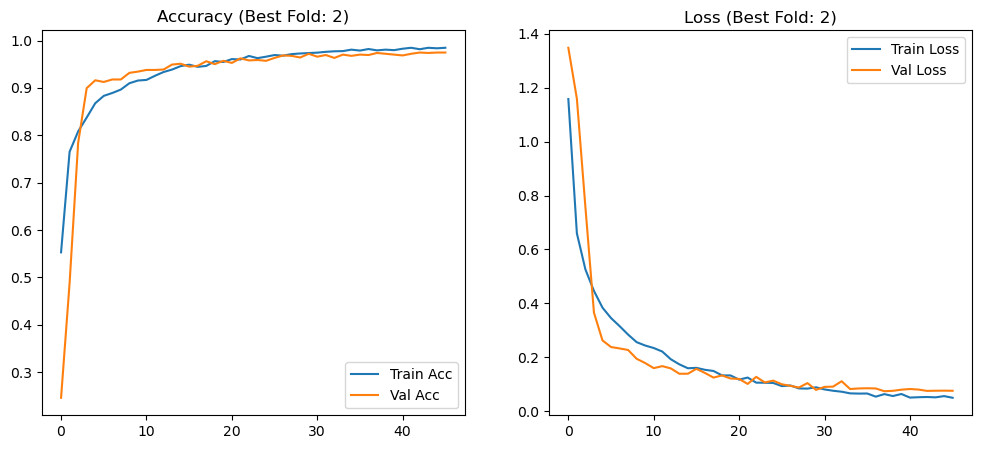

Loading best model from: best_vgg16_fold_2.keras ...


TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 4.0000000467443897e-07, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': 'categorical_crossentropy', 'loss_weights': None, 'metrics': ['accuracy'], 'weighte

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. SETUP STORAGE ---

all_histories = [] 
acc_per_fold = []
loss_per_fold = []
fold_no = 1

# --- 2. TRAINING LOOP ---
for train_index, val_index in kf.split(df):
    print(f"\n--- Training Fold {fold_no} / {N_FOLDS} ---")
    
    train_df = df.iloc[train_index]
    val_df = df.iloc[val_index]
    
    train_datagen = ImageDataGenerator(**train_datagen_args)
    val_datagen = ImageDataGenerator(**val_datagen_args)
    
    train_generator = train_datagen.flow_from_dataframe(
        train_df, x_col='filename', y_col='class',
        target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True
    )
    
    validation_generator = val_datagen.flow_from_dataframe(
        val_df, x_col='filename', y_col='class',
        target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False # Important: Shuffle=False for evaluation
    )
    
    model = build_optimized_vgg_model()
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Class weights calculation
    y_train = train_df['class']
    classes_in_fold = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes_in_fold, y=y_train)
    class_weights_dict = {train_generator.class_indices[cls]: w for cls, w in zip(classes_in_fold, weights)}

    checkpoint_path = f'best_vgg16_fold_{fold_no}.keras'
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=0)
    ]
    
    history = model.fit(
        train_generator, epochs=50, validation_data=validation_generator,
        callbacks=callbacks, class_weight=class_weights_dict
    )
    
    # STORE HISTORY
    all_histories.append(history.history)
    
    scores = model.evaluate(validation_generator, verbose=0)
    print(f'Score for Fold {fold_no}: Accuracy={scores[1]*100:.2f}%')
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])
    # --- DATA COLLECTION FOR STATISTICAL TESTS ---
    # 1. Save raw accuracy (0.0 to 1.0) for Wilcoxon
    fold_accuracies_raw.append(scores[1]) 

    # 2. Save detailed predictions for McNemar
    validation_generator.reset() # Reset to ensure correct order
    preds = model.predict(validation_generator, verbose=0)
    
    y_pred_fold = np.argmax(preds, axis=1) # Convert probs to class ID
    y_true_fold = validation_generator.classes # Get true labels
    
    all_y_true.extend(y_true_fold)
    all_y_pred.extend(y_pred_fold)
    # ---------------------------------------------
    fold_no += 1

# --- 3. IDENTIFY BEST MODEL ---
# Find the index of the fold with the highest validation accuracy
best_fold_index = np.argmax(acc_per_fold) 
best_fold_number = best_fold_index + 1
print(f"\nBEST MODEL: Fold {best_fold_number} with Accuracy: {acc_per_fold[best_fold_index]:.2f}%")

# --- ADD THIS FOR CORRECT REPORTING ---
avg_acc = np.mean(acc_per_fold)
std_acc = np.std(acc_per_fold)

print(f"\n--- Cross-Validation Results ---")
print(f"Average Accuracy: {avg_acc:.2f}% (+/- {std_acc:.2f}%)")
print(f"All Fold Scores: {acc_per_fold}")
print("--------------------------------")

# --- 4. PLOT TRAINING HISTORY ---
best_history = all_histories[best_fold_index]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history['accuracy'], label='Train Acc')
plt.plot(best_history['val_accuracy'], label='Val Acc')
plt.title(f'Accuracy (Best Fold: {best_fold_number})')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title(f'Loss (Best Fold: {best_fold_number})')
plt.legend()
plt.show()

# --- 5. DETAILED EVALUATION (Confusion Matrix, ROC, Report) ---
print(f"Loading best model from: best_vgg16_fold_{best_fold_number}.keras ...")
best_model = load_model(f'best_vgg16_fold_{best_fold_number}.keras')

# Retrieve the validation DataFrame for the best fold
kf_eval = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
current_fold = 0
best_val_df = None

# Loop to find the correct split again
for _, val_idx in kf_eval.split(df):
    if current_fold == best_fold_index:
        best_val_df = df.iloc[val_idx]
        break
    current_fold += 1

Loading best model from: best_vgg16_fold_2.keras ...

------------------------------
Average Scores for all folds:
> Accuracy: 96.83 (+- 0.59)
> Loss: 0.0943
------------------------------
Found 1143 validated image filenames belonging to 4 classes.


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.98      0.97      0.97       275
  meningioma       0.95      0.96      0.96       272
     notumor       1.00      0.99      0.99       312
   pituitary       0.97      0.98      0.98       284

    accuracy                           0.97      1143
   macro avg       0.97      0.97      0.97      1143
weighted avg       0.97      0.97      0.97      1143



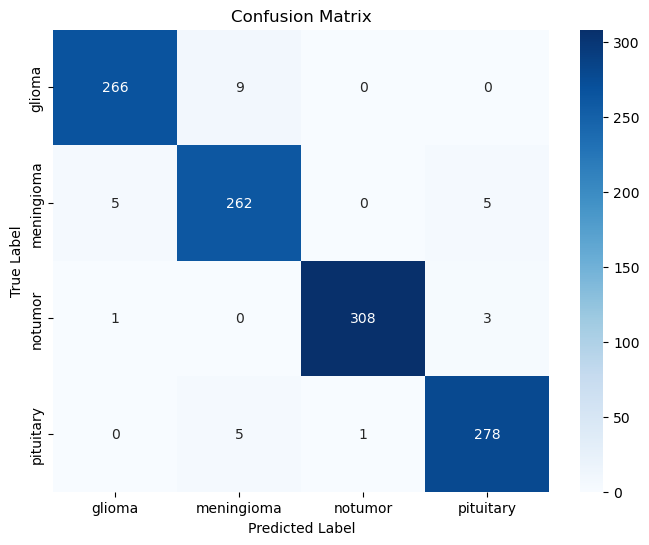

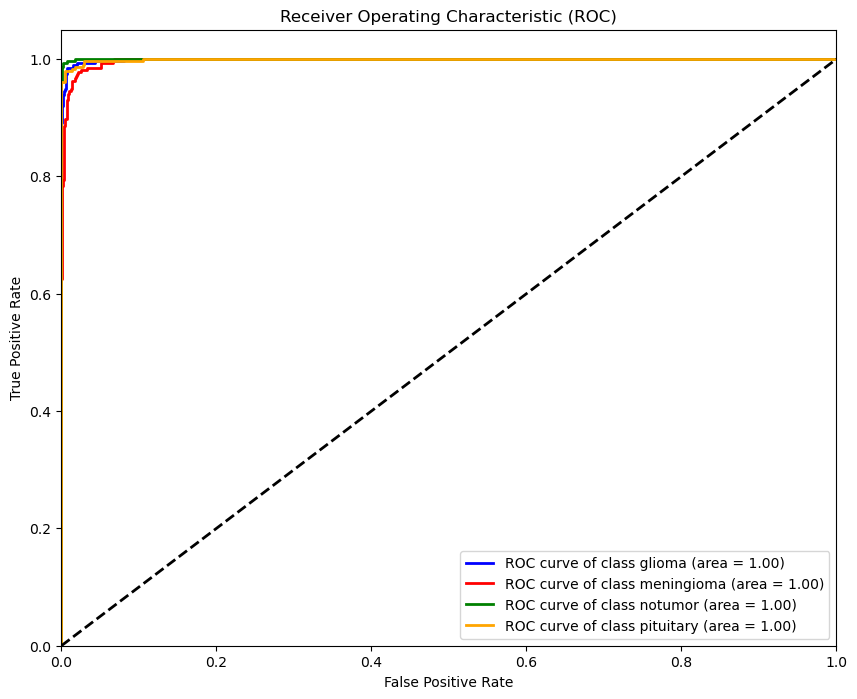

In [6]:
# --- 5. DETAILED EVALUATION (Confusion Matrix, ROC, Report) ---
print(f"Loading best model from: best_vgg16_fold_{best_fold_number}.keras ...")


best_model = load_model(
    f'best_vgg16_fold_{best_fold_number}.keras',
    custom_objects={'ChannelAttention': ChannelAttention} 
)
# --- 5. CV Results Summary ---
print("\n" + "-"*30)
print("Average Scores for all folds:")
print(f"> Accuracy: {np.mean(acc_per_fold):.2f} (+- {np.std(acc_per_fold):.2f})")
print(f"> Loss: {np.mean(loss_per_fold):.4f}")
print("-"*30)
# Retrieve the validation DataFrame for the best fold
kf_eval = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
current_fold = 0
best_val_df = None

# Loop to find the correct split again
for _, val_idx in kf_eval.split(df):
    if current_fold == best_fold_index:
        best_val_df = df.iloc[val_idx]
        break
    current_fold += 1


best_val_gen = val_datagen.flow_from_dataframe(
    best_val_df, x_col='filename', y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Predict
predictions = best_model.predict(best_val_gen)
y_pred_indices = np.argmax(predictions, axis=1)
y_true_indices = best_val_gen.classes
class_labels = list(best_val_gen.class_indices.keys())

# A. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true_indices, y_pred_indices, target_names=class_labels))

# B. Confusion Matrix
cm = confusion_matrix(y_true_indices, y_pred_indices)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# C. ROC-AUC Curve
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(class_labels)

# One-hot encode true labels for ROC calculation
y_true_onehot = tf.keras.utils.to_categorical(y_true_indices, num_classes=n_classes)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange'] 
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

Found 1311 TEST images belonging to 4 classes.

Starting Test Set Evaluation...
Found 1311 validated image filenames belonging to 4 classes.

--- Starting Ensemble Prediction using all 5 models ---
Loading and predicting with: best_vgg16_fold_1.keras...


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Loading and predicting with: best_vgg16_fold_2.keras...
Loading and predicting with: best_vgg16_fold_3.keras...
Loading and predicting with: best_vgg16_fold_4.keras...
Loading and predicting with: best_vgg16_fold_5.keras...
Ensemble prediction complete. Proceeding to evaluation...

--- Test Set Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.95      0.97       300
  meningioma       0.95      0.96      0.96       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.96      1.00      0.98       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



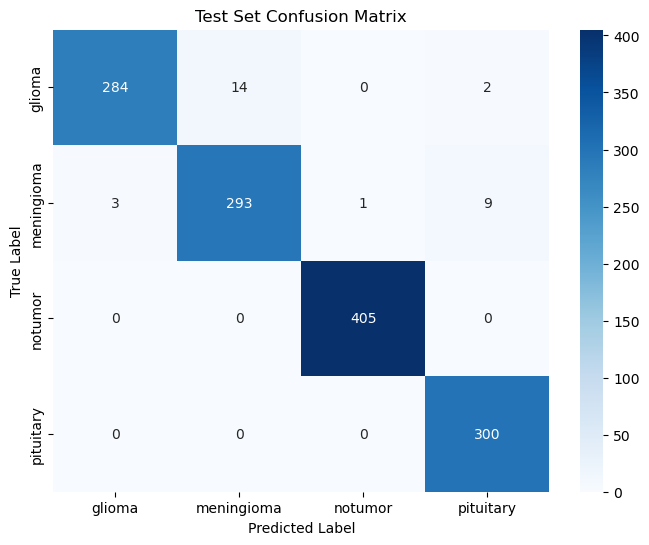

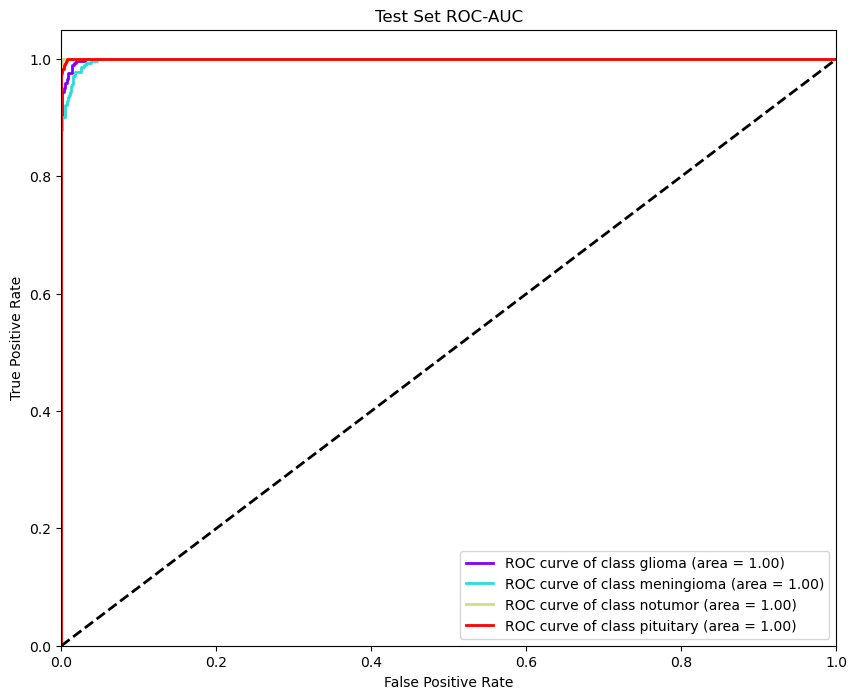


--- Generating Data for Wilcoxon Test ---
SUCCESS: Saved 'vgg16_wilcoxon_data.csv' for statistical comparison.

--- Calculating 95% Confidence Intervals (Bootstrapping 1000 iterations) ---

Results (1000 iterations):
ACCURACY: 0.9779 (95% CI: 0.9695 - 0.9855)
AUC: 0.9995 (95% CI: 0.9991 - 0.9997)
F1: 0.9778 (95% CI: 0.9693 - 0.9855)


In [14]:
# --- LOAD TEST DATA (held-out set) ---
TEST_DIR = 'archive/Testing'  
test_filepaths = []
test_labels = []

if not os.path.exists(TEST_DIR):
    print(f"WARNING: Test directory '{TEST_DIR}' not found. Please check path.")
else:
    test_classes = sorted(os.listdir(TEST_DIR))
    for class_name in test_classes:
        class_dir = os.path.join(TEST_DIR, class_name)
        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):
                test_filepaths.append(os.path.join(class_dir, filename))
                test_labels.append(class_name)

    # Created the DataFrame specifically for Testing
    test_df = pd.DataFrame({
        'filename': test_filepaths,
        'class': test_labels
    })

    print(f"Found {len(test_df)} TEST images belonging to {len(test_classes)} classes.")
    
# --- 6. TEST SET EVALUATION ---
if 'test_df' in locals() and not test_df.empty:
    print("\nStarting Test Set Evaluation...")

    # 1. Create Test Generator
    # We only rescale. No augmentation for testing.
    test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
    )

    test_gen = test_datagen.flow_from_dataframe(
        test_df,
        x_col='filename',
        y_col='class',
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False  # <--- CRITICAL: Must be False to match predictions to labels
    )

    # 2. Predict
   # --- REPLACEMENT: ENSEMBLE PREDICTION (Average of 5 Folds) ---
    print(f"\n--- Starting Ensemble Prediction using all {N_FOLDS} models ---")
    
    # Initialize an empty array to store the sum of predictions
    # Shape: (Number of Test Images, Number of Classes)
    ensemble_sum = np.zeros((len(test_df), NUM_CLASSES))

    # Loop through each saved fold model
    for fold_idx in range(1, N_FOLDS + 1):
        model_filename = f'best_vgg16_fold_{fold_idx}.keras'
        print(f"Loading and predicting with: {model_filename}...")
        
        # Load the specific fold's model
        fold_model = load_model(model_filename, custom_objects={'ChannelAttention': ChannelAttention})
        
        # Predict on the test set
        preds = fold_model.predict(test_gen, verbose=0)
        
        # Add these predictions to our total
        ensemble_sum += preds

    # Divide by N_FOLDS to get the average probability
    test_predictions = ensemble_sum / N_FOLDS

    # Generate the indices and labels (needed for the ROC and Classification Report below)
    test_y_pred_indices = np.argmax(test_predictions, axis=1)
    test_y_true_indices = test_gen.classes
    test_class_labels = list(test_gen.class_indices.keys())

    print("Ensemble prediction complete. Proceeding to evaluation...")

    # A. Classification Report
    print("\n--- Test Set Classification Report ---")
    print(classification_report(test_y_true_indices, test_y_pred_indices, target_names=test_class_labels))

    # B. Confusion Matrix
    test_cm = confusion_matrix(test_y_true_indices, test_y_pred_indices)
    plt.figure(figsize=(8, 6))
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=test_class_labels, yticklabels=test_class_labels)
    plt.title('Test Set Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # C. ROC-AUC Curve
    # One-hot encode true labels for ROC calculation
    n_classes = len(test_class_labels)
    test_y_true_onehot = tf.keras.utils.to_categorical(test_y_true_indices, num_classes=n_classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(test_y_true_onehot[:, i], test_predictions[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    
    # Using a colormap to handle any number of classes automatically
    colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'.format(test_class_labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test Set ROC-AUC')
    plt.legend(loc="lower right")
    plt.show()
    print("\n--- Generating Data for Wilcoxon Test ---")
    
    # 1. Get probability of the TRUE class (for confidence comparison)
    prob_of_true_class = [pred[true_idx] for pred, true_idx in zip(test_predictions, test_y_true_indices)]

    # 2. Get binary correctness (0 or 1)
    is_correct = (test_y_pred_indices == test_y_true_indices).astype(int)

    # 3. Create DataFrame
    wilcoxon_df = pd.DataFrame({
        'filename': test_gen.filenames,        # REQUIRED: To align rows with the other model
        'y_true': test_y_true_indices,
        'y_pred': test_y_pred_indices,
        'prob_true_class': prob_of_true_class, # Use this column for the Wilcoxon test
        'is_correct': is_correct
    })

    # 4. Save
    wilcoxon_df.to_csv('vgg16_wilcoxon_data.csv', index=False)
    print("SUCCESS: Saved 'vgg16_wilcoxon_data.csv' for statistical comparison.")


    # =================================================================
    # === NEW CODE: 95% CONFIDENCE INTERVALS (BOOTSTRAPPING) =========
    # =================================================================
    from sklearn.utils import resample
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

    print("\n--- Calculating 95% Confidence Intervals (Bootstrapping 1000 iterations) ---")
    
    # Configuration
    n_iterations = 1000
    alpha = 0.95
    p = ((1.0 - alpha) / 2.0) * 100 # Lower percentile (2.5%)
    q = (alpha + ((1.0 - alpha) / 2.0)) * 100 # Upper percentile (97.5%)

    # Storage for bootstrapped metrics
    stats = {'accuracy': [], 'auc': [], 'f1': []}
    
    # We need one-hot encoding for AUC inside the loop
    n_classes = len(test_class_labels)

    # Convert to numpy arrays if they aren't already (for safe indexing)
    y_true_all = np.array(test_y_true_indices)
    y_pred_all = np.array(test_y_pred_indices)
    y_proba_all = np.array(test_predictions)

    for i in range(n_iterations):
        # 1. Resample indices with replacement
        # We resample the indices, then select data based on them to keep pairs intact
        indices = resample(np.arange(len(y_true_all)), replace=True)
        
        # 2. Select data for this iteration
        y_true_boot = y_true_all[indices]
        y_pred_boot = y_pred_all[indices]
        y_proba_boot = y_proba_all[indices]
        
        # 3. Calculate Metrics
        # Accuracy
        acc = accuracy_score(y_true_boot, y_pred_boot)
        
        # F1 Score (Weighted is standard for multi-class imbalance, change to 'macro' if preferred)
        f1 = f1_score(y_true_boot, y_pred_boot, average='weighted')
        
        # AUC (Handling multi-class requires One-Hot encoding for the specific bootstrap sample)
        
        try:
           
            y_true_boot_onehot = tf.keras.utils.to_categorical(y_true_boot, num_classes=n_classes)
            auc_score = roc_auc_score(y_true_boot_onehot, y_proba_boot, multi_class='ovr', average='weighted')
        except ValueError:
            # If a class is completely missing in the sample, skip this iteration or use NaN
            auc_score = np.nan

        stats['accuracy'].append(acc)
        stats['f1'].append(f1)
        if not np.isnan(auc_score):
            stats['auc'].append(auc_score)

    # 4. Compute Confidence Intervals
    print(f"\nResults ({n_iterations} iterations):")
    
    for metric_name, values in stats.items():
        # Sort the results
        values.sort()
        
        # Calculate lower and upper bounds
        lower = np.percentile(values, p)
        upper = np.percentile(values, q)
        mean_val = np.mean(values)
        
        print(f"{metric_name.upper()}: {mean_val:.4f} (95% CI: {lower:.4f} - {upper:.4f})")
else:
    print("Test DataFrame is empty or not defined. Skipping evaluation.")

In [8]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """ Generates the Grad-CAM heatmap. """
    
   
    input_tensor = model.inputs[0] if isinstance(model.inputs, list) else model.inputs
    
    # Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = Model(
        inputs=input_tensor, 
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Cast img_array to float32 to ensure compatibility
        inputs = tf.cast(img_array, tf.float32)

        tape.watch(inputs)
        
        # Pass the image through the grad_model
        last_conv_layer_output, preds = grad_model(inputs)
        
        # If no specific class index is provided, uses the predicted class
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
            
        # Get the score for the target class
        class_channel = preds[:, pred_index]

    # Compute the gradient of the output neuron with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over the height and width axes (Global Average Pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by 'how important this channel is'
    last_conv_layer_output = last_conv_layer_output[0]
    
    # Matrix multiplication between the feature map and the pooled gradients
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    
    # Squeeze to remove extra dimensions
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()


--- DIAGNOSTICS ---
True Class Mapping from Training: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training used specific Preprocessing Function (e.g., VGG preprocess_input)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step

PREDICTION RESULTS:
Raw Output Vector: [[9.9999988e-01 3.3570704e-08 1.6437909e-08 4.4755886e-08]]
Predicted Index: 0
Mapped Label: glioma (Confidence: 100.00%)


C:\Users\VICKY\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


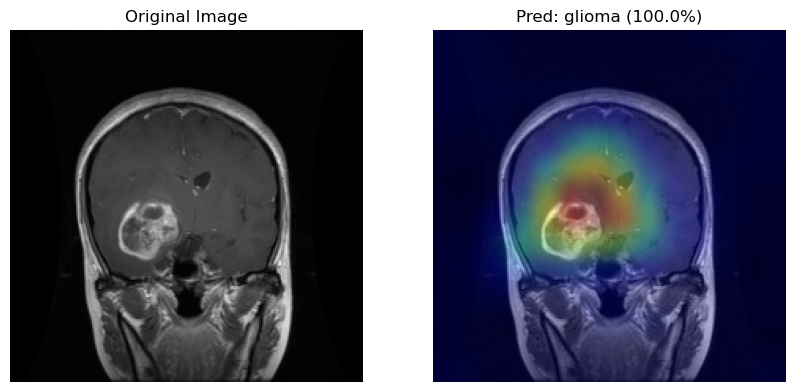

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model

# ==========================================
# 1. DIAGNOSE THE MAPPING & PREPROCESSING
# ==========================================

# A. Get the EXACT class mapping from the generator
# The generator knows the truth (e.g., {'glioma': 0, 'meningioma': 1, ...})
true_labels_map = train_generator.class_indices 
idx_to_label = {v: k for k, v in true_labels_map.items()}

print("\n--- DIAGNOSTICS ---")
print(f"True Class Mapping from Training: {true_labels_map}")

# B. Check Preprocessing Logic
# We inspect the arguments you passed to ImageDataGenerator
if 'rescale' in train_datagen_args and train_datagen_args['rescale'] is not None:
    print(f"Training used Rescaling: {train_datagen_args['rescale']}")
    MODE = "RESCALE"
elif 'preprocessing_function' in train_datagen_args and train_datagen_args['preprocessing_function'] is not None:
    print("Training used specific Preprocessing Function (e.g., VGG preprocess_input)")
    MODE = "PREPROCESS_INPUT"
else:
    print("WARNING: No rescale or preprocessing function found. Model expects 0-255 raw pixels?")
    MODE = "RAW"

# ==========================================
# 2. ROBUST GRAD-CAM FUNCTION
# ==========================================

def get_img_array_robust(img_path, size, mode):
    # Load image
    img = tf.keras.utils.load_img(img_path, target_size=size)
    array = tf.keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    
    # Apply the EXACT same preprocessing as training
    if mode == "RESCALE":
        array = array * train_datagen_args['rescale'] # e.g. multiply by 1/255
    elif mode == "PREPROCESS_INPUT":
        # Assuming VGG16 standard preprocessing if function was used
        array = tf.keras.applications.vgg16.preprocess_input(array)
        
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Find the layer if name is incorrect
    try:
        model.get_layer(last_conv_layer_name)
    except ValueError:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer_name = layer.name
                break
    
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ==========================================
# 3. RUN ON YOUR IMAGE
# ==========================================

target_image_path = 'archive/Testing/glioma/Te-gl_0068.jpg' 
last_conv_layer = "block5_conv3" # VGG16 standard

if os.path.exists(target_image_path):
    # 1. Preprocess using detected mode
    img_array = get_img_array_robust(target_image_path, (IMG_SIZE, IMG_SIZE), MODE)
    
    # 2. Predict
    preds = best_model.predict(img_array)
    pred_index = np.argmax(preds)
    confidence = np.max(preds) * 100
    
    # 3. Decode Label using the TRUE mapping
    pred_label = idx_to_label[pred_index]
    
    print(f"\nPREDICTION RESULTS:")
    print(f"Raw Output Vector: {preds}")
    print(f"Predicted Index: {pred_index}")
    print(f"Mapped Label: {pred_label} (Confidence: {confidence:.2f}%)")
    
    # 4. Generate Heatmap
    heatmap = make_gradcam_heatmap(img_array, best_model, last_conv_layer)
    
    # 5. Display
    img = cv2.imread(target_image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((IMG_SIZE, IMG_SIZE))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    
    superimposed_img = jet_heatmap * 0.4 + img_rgb
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Pred: {pred_label} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

else:
    print("Image not found.")

In [10]:
import pandas as pd
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon

# --- 1. SAVE CURRENT MODEL DATA ---
# Save detailed predictions
df_detailed_m1 = pd.DataFrame({
    'y_true': all_y_true, 
    'y_pred': all_y_pred
})
df_detailed_m1.to_csv('VGG16_5fold_Detailed.csv', index=False)

# Saved fold scores
df_scores_m1 = pd.DataFrame({
    'Fold': range(1, len(fold_accuracies_raw) + 1),
    'Accuracy': fold_accuracies_raw
})
df_scores_m1.to_csv('VGG16_5fold_Fold_Scores.csv', index=False)
print("Current model data saved.")

Current model data saved.


SUCCESS: Found model file: 'best_vgg16_fold_1.keras'
Loading model...

Model loaded successfully!

 RESULTS FOR JOURNAL (best_vgg16_fold_1.keras)
Attention Entropy: 9.0000 bits
Focus Metric: 461 channels explain 90% of importance.


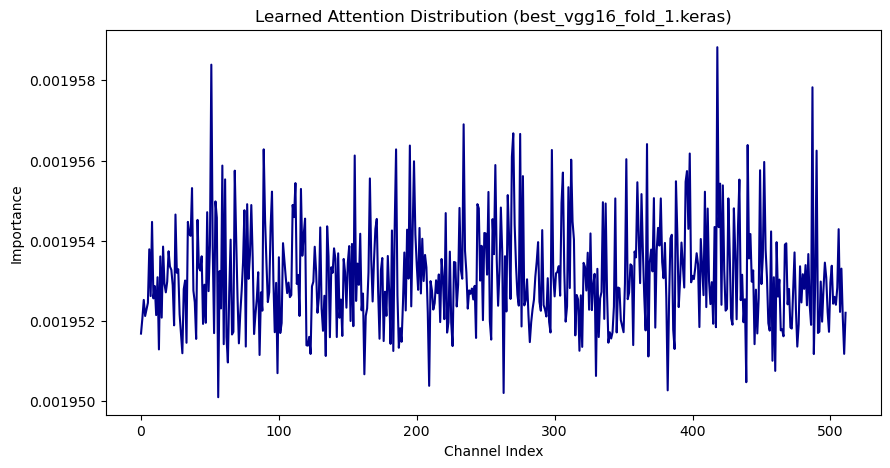

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import tensorflow as tf
from tensorflow.keras import layers

# --- STEP 1: RE-DEFINE THE CUSTOM LAYER (Required to load the model) ---
class ChannelAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.w = self.add_weight(name='attention_weights',
                                 shape=(self.channels,),
                                 initializer='ones',
                                 trainable=True)
        super(ChannelAttention, self).build(input_shape)

    def call(self, x):
       
        w_attr = tf.nn.softmax(self.w)
        return x * w_attr

    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        return config


found_files = glob.glob("best_vgg16_fold_*.keras")

if not found_files:
    
    print("No model files found with pattern 'best_vgg16_fold_*.keras'.")
    print("Checking for ANY .keras file...")
    found_files = glob.glob("*.keras")

if not found_files:
    raise ValueError("CRITICAL ERROR: No .keras model file found in the current directory. "
                     "You must re-run the 'Training' section of your notebook to generate the model file.")

target_file = found_files[0] # Pick the first one found (usually the best fold)
print(f"SUCCESS: Found model file: '{target_file}'")
print("Loading model...")

# Load with the custom object scope
model = tf.keras.models.load_model(target_file, custom_objects={'ChannelAttention': ChannelAttention})
print("Model loaded successfully!")

# --- STEP 3: CALCULATE ATTENTION ENTROPY ---

attn_layer = None
for layer in model.layers:
    if 'ChannelAttention' in str(type(layer)) or 'ChannelAttention' in layer.name:
        attn_layer = layer
        break

if attn_layer is None:
    print("Warning: Could not find layer by name/type. Searching by weight shape (512,)...")
    for layer in model.layers:
        weights = layer.get_weights()
        if len(weights) > 0 and weights[0].shape == (512,):
            attn_layer = layer
            print(f"Found candidate layer: {layer.name}")
            break

if attn_layer:
    learned_weights = attn_layer.get_weights()[0]
    
    # Softmax
    def softmax(x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()
    
    attention_scores = softmax(learned_weights)
    
    # Entropy
    attn_entropy = entropy(attention_scores, base=2)
    max_entropy = np.log2(len(attention_scores))
    
    # Focus (Top 90%)
    sorted_indices = np.argsort(attention_scores)[::-1]
    cumulative_sum = np.cumsum(attention_scores[sorted_indices])
    n_channels_90 = np.searchsorted(cumulative_sum, 0.90) + 1
    
    print("\n" + "="*40)
    print(f" RESULTS FOR JOURNAL ({target_file})")
    print("="*40)
    print(f"Attention Entropy: {attn_entropy:.4f} bits")
    print(f"Focus Metric: {n_channels_90} channels explain 90% of importance.")
    print("="*40)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(attention_scores, color='darkblue')
    plt.title(f"Learned Attention Distribution ({target_file})")
    plt.xlabel("Channel Index")
    plt.ylabel("Importance")
    plt.show()
else:
    print("Could not extract attention weights. Please check model architecture.")